### Clean all the Powder Patch data from MesoWest - Synoptic Weather API

Notebook contents 
* loading all the data that I could download from Powder Patch (starting 2014 earliest) on the MesoWest (not Mesonet) Synoptic Weather API
* Making a copy of the `load..` notebook, and cleaning and smoothing the data here 

created by Cassie Lumbrazo\
last updated: July 2025\
run location: UAS linux\
python environment: **xarray**

In [1]:
# import packages 
%matplotlib inline

# plotting packages 
import matplotlib as mpl
import matplotlib.pyplot as plt
import seaborn as sns 

sns.set_theme()
plt.rcParams['figure.figsize'] = [12,6] #overriding size

# data packages 
import pandas as pd
import numpy as np
import xarray as xr
from datetime import datetime

import scipy

from matplotlib.patches import Patch
from matplotlib.colors import ListedColormap
from matplotlib import ticker

import matplotlib.colors as mcolors
import matplotlib.cm as cm
import matplotlib 

In [2]:
pwd

'/home/cassie/python/repos/juneau_data_analysis'

In [3]:
filename = '/home/cassie/data/fishcreek/mesowest/rawdata/PPSA2_Synoptic_everything_utc_time_remove_header.csv'
df_mesowest= pd.read_csv(filename, sep = ",") #  low_memory=False

# Convert 'Date_Time' to datetime, skipping the first row (units row)
df_mesowest = df_mesowest.iloc[1:].copy()
df_mesowest['datetime'] = pd.to_datetime(df_mesowest['Date_Time'], utc=True)
# set datetime as the index
df_mesowest.set_index('datetime', inplace=True)
df_mesowest.head()

/tmp/ipykernel_902535/260331117.py:2: DtypeWarning: Columns (2,3,4,5,6,7,8,9) have mixed types. Specify dtype option on import or set low_memory=False.
  df_mesowest= pd.read_csv(filename, sep = ",") #  low_memory=False


,Station_ID,Date_Time,air_temp_set_1,relative_humidity_set_1,snow_depth_set_1,precip_accum_set_1,volt_set_1,snow_interval_set_1,heat_index_set_1d,dew_point_temperature_set_1d
datetime,,,,,,,,,,
2014-01-09 15:00:00+00:00,PPSA2,2014-01-09T15:00:00Z,-1.43,91.9,NaN,NaN,NaN,NaN,NaN,-2.59
2014-01-09 15:30:00+00:00,PPSA2,2014-01-09T15:30:00Z,-1.38,92.0,NaN,NaN,NaN,NaN,NaN,-2.53
2014-01-09 16:00:00+00:00,PPSA2,2014-01-09T16:00:00Z,-1.38,91.9,NaN,NaN,NaN,NaN,NaN,-2.54
2014-01-09 16:30:00+00:00,PPSA2,2014-01-09T16:30:00Z,-1.38,91.9,NaN,NaN,NaN,NaN,NaN,-2.54
2014-01-09 17:00:00+00:00,PPSA2,2014-01-09T17:00:00Z,-1.38,91.8,NaN,NaN,NaN,NaN,NaN,-2.56


In [4]:
# save only the df_mesowest['snow_depth_set_1] to a new clean df dataframe 
df = df_mesowest['snow_depth_set_1'].to_frame()

# change the column name to simply hs 
df.rename(columns={'snow_depth_set_1': 'hs'}, inplace=True)

<Axes: xlabel='datetime'>

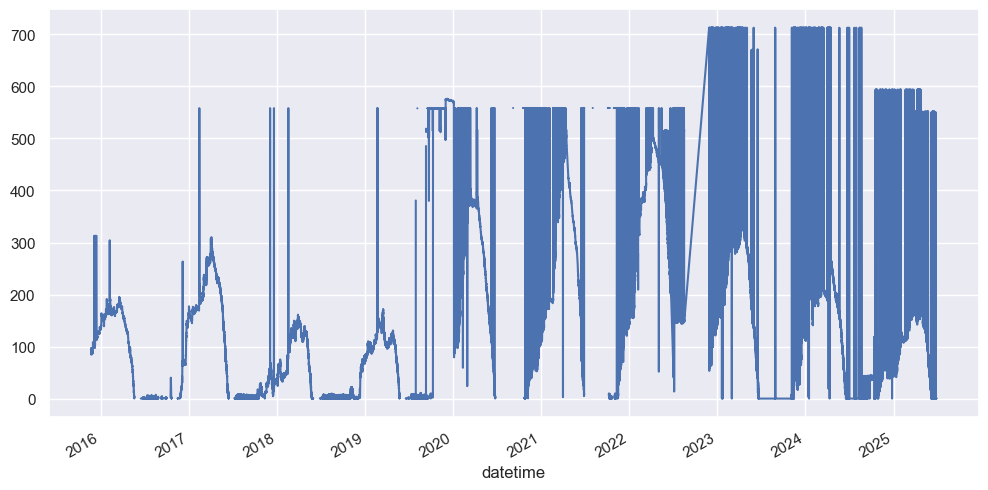

In [5]:
# change the data type of df['hs'] to int
# also need to deal with the nan values, "cannot convert float nana to integar"
df['hs'] = pd.to_numeric(df['hs'], errors='coerce')  # Convert to numeric, coercing errors to NaN
# df['hs'].fillna(0, inplace=True)  # Replace NaN with
# df['hs'] = df['hs'].astype(int)
df['hs'] = df['hs'] / 10 # convert mm to cm 
df['hs'].plot()

Some cleaning, 

In [6]:
# Step 1: Compute water year (1 Oct - 30 Sept)
df['datetime'] = pd.to_datetime(df.index)  # Ensure datetime
df['water_year'] = df['datetime'].apply(
    lambda d: d.year + 1 if d.month >= 10 else d.year
)

df

,hs,datetime,water_year
datetime,,,
2014-01-09 15:00:00+00:00,NaN,2014-01-09 15:00:00+00:00,2014
2014-01-09 15:30:00+00:00,NaN,2014-01-09 15:30:00+00:00,2014
2014-01-09 16:00:00+00:00,NaN,2014-01-09 16:00:00+00:00,2014
2014-01-09 16:30:00+00:00,NaN,2014-01-09 16:30:00+00:00,2014
2014-01-09 17:00:00+00:00,NaN,2014-01-09 17:00:00+00:00,2014
...,...,...,...
2025-06-27 08:00:00+00:00,0.381,2025-06-27 08:00:00+00:00,2025
2025-06-27 09:00:00+00:00,0.000,2025-06-27 09:00:00+00:00,2025
2025-06-27 10:00:00+00:00,0.000,2025-06-27 10:00:00+00:00,2025


In [7]:
# print the max value for each water_year
for col in ['hs']:
    if col in df.columns:
        print(f"\nMaximum values of {col} by water year:")
        print(df.groupby('water_year')[col].max())


Maximum values of hs by water year:
water_year
2014         NaN
2015         NaN
2016    312.8010
2017    558.2920
2018    558.2920
2019    558.2920
2020    576.3006
2021    558.5968
2022    558.5968
2023    713.0034
2024    713.0034
2025    594.0044
Name: hs, dtype: float64


In [8]:
df['hs_clean'] = df['hs'].copy(deep=True)

In [9]:
df.head()

,hs,datetime,water_year,hs_clean
datetime,,,,
2014-01-09 15:00:00+00:00,NaN,2014-01-09 15:00:00+00:00,2014,NaN
2014-01-09 15:30:00+00:00,NaN,2014-01-09 15:30:00+00:00,2014,NaN
2014-01-09 16:00:00+00:00,NaN,2014-01-09 16:00:00+00:00,2014,NaN
2014-01-09 16:30:00+00:00,NaN,2014-01-09 16:30:00+00:00,2014,NaN
2014-01-09 17:00:00+00:00,NaN,2014-01-09 17:00:00+00:00,2014,NaN


In [10]:
# Step 2: Define water year max thresholds
wy_max_depth = {
    2012: 600, # mesonet only, not great 
    2013: 600, # mesonet only, not great 
    2014: 600, # mesonet only, not great 
    2015: 600, # mesonet only, not great 
    2016: 250,
    2017: 350,
    2018: 350,
    2019: 250,
    2020: 450, # the data for this year is pretty tough, might need to remove a lot.. come back to this value 
    2021: 500,
    2022: 500,
    2023: 400,
    2024: 400,
    2025: 250,
}

# Step 3: Clean snow depth columns based on water year-specific max
for col in ['hs_clean']:
    if col in df.columns:
        df[col] = df.apply(
            lambda row: row[col] if (0 <= row[col] <= wy_max_depth.get(row['water_year'], 450)) else None,
            axis=1
        )

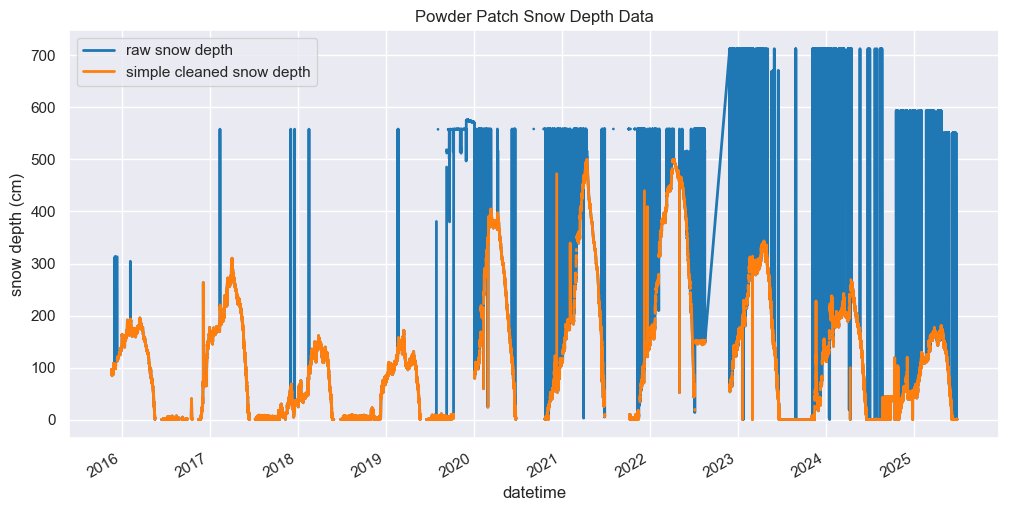

In [11]:
plt.figure(figsize=(12, 6))
plt.title('Powder Patch Snow Depth Data')
plt.ylabel('snow depth (cm)')
df['hs'].plot(label='raw snow depth', color='tab:blue', linewidth=2)
df['hs_clean'].plot(label='simple cleaned snow depth', color='tab:orange', linewidth=2)
plt.legend(loc='upper left')

In [ ]:
# Set hs_clean > 50 cm to NaN for July, August, or September (add October)
mask = (df['datetime'].dt.month.isin([7, 8, 9, 10])) & (df['hs_clean'] > 30)
df.loc[mask, 'hs_clean'] = np.nan

# Smoothing with LOESS (or LOWESS) 
A good choice for smoothing nonlinear trends in snow depth while preserving local structure. It's especially useful if your data is seasonal, noisy, and has irregular ups/downs.


In [13]:
from statsmodels.nonparametric.smoothers_lowess import lowess

The current datetime "DatetimeIndex" is timezone-aware (it ends in +00:00), but the snow_year_start timestamps created in the function get_snow_year_day() are timezone-naive (i.e., no timezone information). Subtracting those two types triggers the TypeError.

Thus, we need to remove the timezone info to make everything timezone-naive before doing date math. 

In [14]:
# Remove timezone info to make datetime index tz-naive
df.index = df.index.tz_convert(None)
df.head()

,hs,datetime,water_year,hs_clean
datetime,,,,
2014-01-09 15:00:00,NaN,2014-01-09 15:00:00+00:00,2014,NaN
2014-01-09 15:30:00,NaN,2014-01-09 15:30:00+00:00,2014,NaN
2014-01-09 16:00:00,NaN,2014-01-09 16:00:00+00:00,2014,NaN
2014-01-09 16:30:00,NaN,2014-01-09 16:30:00+00:00,2014,NaN
2014-01-09 17:00:00,NaN,2014-01-09 17:00:00+00:00,2014,NaN


In [15]:
df['datetime'] = df.index  # Create a datetime column for further processing
df

,hs,datetime,water_year,hs_clean
datetime,,,,
2014-01-09 15:00:00,NaN,2014-01-09 15:00:00,2014,NaN
2014-01-09 15:30:00,NaN,2014-01-09 15:30:00,2014,NaN
2014-01-09 16:00:00,NaN,2014-01-09 16:00:00,2014,NaN
2014-01-09 16:30:00,NaN,2014-01-09 16:30:00,2014,NaN
2014-01-09 17:00:00,NaN,2014-01-09 17:00:00,2014,NaN
...,...,...,...,...
2025-06-27 08:00:00,0.381,2025-06-27 08:00:00,2025,0.381
2025-06-27 09:00:00,0.000,2025-06-27 09:00:00,2025,0.000
2025-06-27 10:00:00,0.000,2025-06-27 10:00:00,2025,0.000


In [16]:
df['doy'] = df['datetime'].dt.dayofyear
df.head()

,hs,datetime,water_year,hs_clean,doy
datetime,,,,,
2014-01-09 15:00:00,NaN,2014-01-09 15:00:00,2014,NaN,9
2014-01-09 15:30:00,NaN,2014-01-09 15:30:00,2014,NaN,9
2014-01-09 16:00:00,NaN,2014-01-09 16:00:00,2014,NaN,9
2014-01-09 16:30:00,NaN,2014-01-09 16:30:00,2014,NaN,9
2014-01-09 17:00:00,NaN,2014-01-09 17:00:00,2014,NaN,9


Doing the most simple first, 

In [17]:
# frac = 0.01
# df['hs_smooth'] = lowess(df['hs_clean'], frac=frac, return_sorted=False, exog='doy')
# df['hs_smooth']

The code below was trying to replicate Jason's method using dates... but it's not working for me. 

In [18]:
# # Make sure your dataframe has 'doy' and 'hs_clean' as numeric columns
# df = df.copy().dropna(subset=['hs_clean', 'doy'])  # Drop rows with missing values if needed

# # Calculate the span of time (for dynamic frac)
# timespan = df['doy'].iloc[-1] - df['doy'].iloc[0]

# # Perform LOWESS smoothing
# hs_smooth = lowess(
#     endog=df['hs_clean'],  # what you're smoothing (snow depth)
#     exog=df['doy'],        # the independent variable (day-of-year)
#     frac=1/timespan,       # smoothing parameter
#     it=1,                  # number of robustifying iterations
#     delta=0.1,             # performance speedup for dense x data
#     return_sorted=False    # return in same order as input
# )

# # Add to your DataFrame (optional)
# df['hs_smooth'] = hs_smooth
# df.head()

In [19]:
# Compute water_doy (Day of Water Year starting Oct 1)
def compute_water_doy(dt):
    wy_start = pd.Timestamp(year=dt.year if dt.month >= 10 else dt.year - 1, month=10, day=1)
    return (dt - wy_start).days + 1

df['water_doy'] = df['datetime'].apply(compute_water_doy)
df.head()

,hs,datetime,water_year,hs_clean,doy,water_doy
datetime,,,,,,
2014-01-09 15:00:00,NaN,2014-01-09 15:00:00,2014,NaN,9,101
2014-01-09 15:30:00,NaN,2014-01-09 15:30:00,2014,NaN,9,101
2014-01-09 16:00:00,NaN,2014-01-09 16:00:00,2014,NaN,9,101
2014-01-09 16:30:00,NaN,2014-01-09 16:30:00,2014,NaN,9,101
2014-01-09 17:00:00,NaN,2014-01-09 17:00:00,2014,NaN,9,101


Trying other methods..

In [20]:
# Compute water year
df['water_year'] = df['datetime'].apply(lambda d: d.year + 1 if d.month >= 10 else d.year)

# Compute start datetime of each row's water year
df['water_year_start'] = df['water_year'].apply(lambda wy: pd.Timestamp(f"{wy-1}-10-01"))

# Compute continuous time axis: days since start of first water year
first_water_year_start = df['water_year_start'].min()
df['day_since_first_wy'] = (df['datetime'] - first_water_year_start).dt.days

# Drop missing data
df = df.dropna(subset=['hs_clean', 'day_since_first_wy'])

# LOWESS smoothing
frac = 0.01  # 10% of points for local regression
df['hs_smooth'] = lowess(
    endog=df['hs_clean'],
    exog=df['day_since_first_wy'],
    frac=frac,
    it=1,
    delta=0.1,
    return_sorted=False
)
df

/tmp/ipykernel_902535/3059474968.py:16: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  df['hs_smooth'] = lowess(


,hs,datetime,water_year,hs_clean,doy,water_doy,water_year_start,day_since_first_wy,hs_smooth
datetime,,,,,,,,,
2015-11-20 22:00:00,96.2914,2015-11-20 22:00:00,2016,96.2914,324,51,2015-10-01,780,88.322523
2015-11-20 23:00:00,96.2914,2015-11-20 23:00:00,2016,96.2914,324,51,2015-10-01,780,88.322523
2015-11-21 00:00:00,95.1992,2015-11-21 00:00:00,2016,95.1992,325,52,2015-10-01,781,89.381671
2015-11-21 01:00:00,94.5896,2015-11-21 01:00:00,2016,94.5896,325,52,2015-10-01,781,89.381671
2015-11-21 02:00:00,94.5896,2015-11-21 02:00:00,2016,94.5896,325,52,2015-10-01,781,89.381671
...,...,...,...,...,...,...,...,...,...
2025-06-27 08:00:00,0.3810,2025-06-27 08:00:00,2025,0.3810,178,270,2024-10-01,4287,-1.142813
2025-06-27 09:00:00,0.0000,2025-06-27 09:00:00,2025,0.0000,178,270,2024-10-01,4287,-1.142813
2025-06-27 10:00:00,0.0000,2025-06-27 10:00:00,2025,0.0000,178,270,2024-10-01,4287,-1.142813


In [21]:
# LOWESS smoothing
frac = 0.001  # 0.1% of points for local regression
df['hs_smooth_001'] = lowess(
    endog=df['hs_clean'],
    exog=df['day_since_first_wy'],
    frac=frac,
    it=1,
    delta=0.1,
    return_sorted=False
)

frac = 0.002  # 0.2% of points for local regression
df['hs_smooth_002'] = lowess(
    endog=df['hs_clean'],
    exog=df['day_since_first_wy'],
    frac=frac,
    it=1,
    delta=0.1,
    return_sorted=False
)

frac = 0.005  # 0.5% of points for local regression
df['hs_smooth_005'] = lowess(
    endog=df['hs_clean'],
    exog=df['day_since_first_wy'],
    frac=frac,
    it=1,
    delta=0.1,
    return_sorted=False
)

df

/tmp/ipykernel_902535/541916181.py:3: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  df['hs_smooth_001'] = lowess(
/tmp/ipykernel_902535/541916181.py:13: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  df['hs_smooth_002'] = lowess(
/tmp/ipykernel_902535/541916181.py:23: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/i

,hs,datetime,water_year,hs_clean,doy,water_doy,water_year_start,day_since_first_wy,hs_smooth,hs_smooth_001,hs_smooth_002,hs_smooth_005
datetime,,,,,,,,,,,,
2015-11-20 22:00:00,96.2914,2015-11-20 22:00:00,2016,96.2914,324,51,2015-10-01,780,88.322523,95.836258,91.615085,91.548294
2015-11-20 23:00:00,96.2914,2015-11-20 23:00:00,2016,96.2914,324,51,2015-10-01,780,88.322523,95.836258,91.615085,91.548294
2015-11-21 00:00:00,95.1992,2015-11-21 00:00:00,2016,95.1992,325,52,2015-10-01,781,89.381671,92.736468,91.936690,91.640169
2015-11-21 01:00:00,94.5896,2015-11-21 01:00:00,2016,94.5896,325,52,2015-10-01,781,89.381671,92.736468,91.936690,91.640169
2015-11-21 02:00:00,94.5896,2015-11-21 02:00:00,2016,94.5896,325,52,2015-10-01,781,89.381671,92.736468,91.936690,91.640169
...,...,...,...,...,...,...,...,...,...,...,...,...
2025-06-27 08:00:00,0.3810,2025-06-27 08:00:00,2025,0.3810,178,270,2024-10-01,4287,-1.142813,0.070126,0.188236,0.139855
2025-06-27 09:00:00,0.0000,2025-06-27 09:00:00,2025,0.0000,178,270,2024-10-01,4287,-1.142813,0.070126,0.188236,0.139855
2025-06-27 10:00:00,0.0000,2025-06-27 10:00:00,2025,0.0000,178,270,2024-10-01,4287,-1.142813,0.070126,0.188236,0.139855


In [22]:
# for the hs_smoothed, drop any snow depth values that are less than 0
df['hs_smooth'] = df['hs_smooth'].where(df['hs_smooth'] >= 0, np.nan)
df['hs_smooth_001'] = df['hs_smooth_001'].where(df['hs_smooth_001'] >= 0, np.nan)
df['hs_smooth_002'] = df['hs_smooth_002'].where(df['hs_smooth_002'] >= 0, np.nan)
df['hs_smooth_005'] = df['hs_smooth_005'].where(df['hs_smooth_005'] >= 0, np.nan)

/tmp/ipykernel_902535/301005045.py:2: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  df['hs_smooth'] = df['hs_smooth'].where(df['hs_smooth'] >= 0, np.nan)
/tmp/ipykernel_902535/301005045.py:3: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  df['hs_smooth_001'] = df['hs_smooth_001'].where(df['hs_smooth_001'] >= 0, np.nan)
/tmp/ipykernel_902535/301005045.py:4: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See t

In [23]:
# # Drop missing data
# df = df.dropna(subset=['hs_clean', 'water_doy'])

# # Apply LOWESS smoothing with fixed frac = 0.1
# frac = 0.1  # 10% of points used in each local regression
# df['hs_smooth'] = lowess(
#     endog=df['hs_clean'],             # dependent variable (snow depth)
#     exog=df['water_doy'],       # independent variable (day of water year)
#     frac=frac,
#     it=1,
#     delta=0.1,
#     return_sorted=False
# )
# df

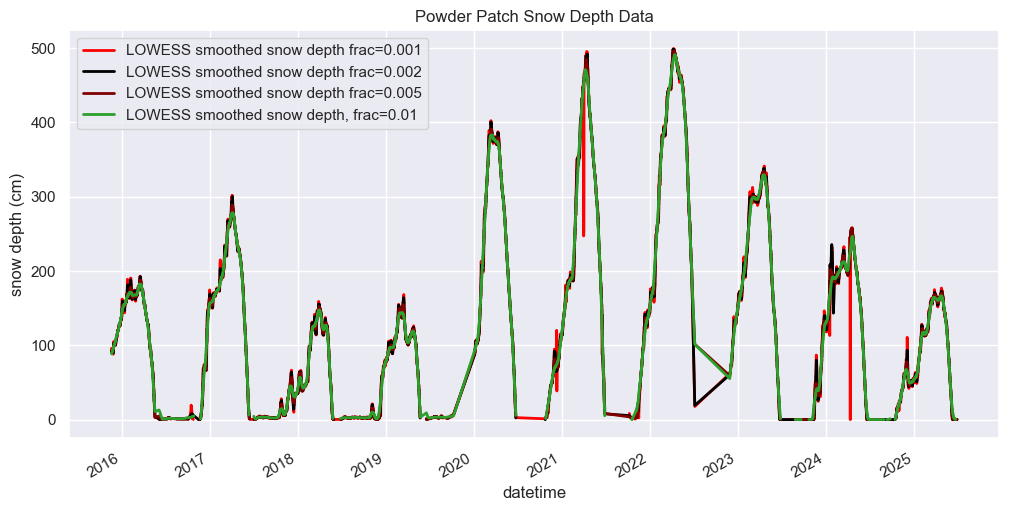

In [24]:
plt.figure(figsize=(12, 6))
plt.title('Powder Patch Snow Depth Data')
plt.ylabel('snow depth (cm)')
# df['hs'].plot(label='raw snow depth', color='tab:blue', linewidth=2)
# df['hs_clean'].plot(label='simple cleaned snow depth', color='tab:orange', linewidth=2)
df['hs_smooth_001'].plot(label='LOWESS smoothed snow depth frac=0.001', color='red', linewidth=2)
df['hs_smooth_002'].plot(label='LOWESS smoothed snow depth frac=0.002', color='black', linewidth=2)
df['hs_smooth_005'].plot(label='LOWESS smoothed snow depth frac=0.005', color='maroon', linewidth=2)
df['hs_smooth'].plot(label='LOWESS smoothed snow depth, frac=0.01', color='tab:green', linewidth=2)

plt.legend(loc='upper left')

## Plotting..

In [25]:
def get_snow_year_day(dt):
    snow_year_start = pd.Timestamp(year=dt.year if dt.month >= 9 else dt.year - 1, month=9, day=1)
    return (dt - snow_year_start).days

df['snow_year_day'] = df.index.map(get_snow_year_day)

/tmp/ipykernel_902535/1421631693.py:5: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  df['snow_year_day'] = df.index.map(get_snow_year_day)


In [26]:
df

,hs,datetime,water_year,hs_clean,doy,water_doy,water_year_start,day_since_first_wy,hs_smooth,hs_smooth_001,hs_smooth_002,hs_smooth_005,snow_year_day
datetime,,,,,,,,,,,,,
2015-11-20 22:00:00,96.2914,2015-11-20 22:00:00,2016,96.2914,324,51,2015-10-01,780,88.322523,95.836258,91.615085,91.548294,80
2015-11-20 23:00:00,96.2914,2015-11-20 23:00:00,2016,96.2914,324,51,2015-10-01,780,88.322523,95.836258,91.615085,91.548294,80
2015-11-21 00:00:00,95.1992,2015-11-21 00:00:00,2016,95.1992,325,52,2015-10-01,781,89.381671,92.736468,91.936690,91.640169,81
2015-11-21 01:00:00,94.5896,2015-11-21 01:00:00,2016,94.5896,325,52,2015-10-01,781,89.381671,92.736468,91.936690,91.640169,81
2015-11-21 02:00:00,94.5896,2015-11-21 02:00:00,2016,94.5896,325,52,2015-10-01,781,89.381671,92.736468,91.936690,91.640169,81
...,...,...,...,...,...,...,...,...,...,...,...,...,...
2025-06-27 08:00:00,0.3810,2025-06-27 08:00:00,2025,0.3810,178,270,2024-10-01,4287,NaN,0.070126,0.188236,0.139855,299
2025-06-27 09:00:00,0.0000,2025-06-27 09:00:00,2025,0.0000,178,270,2024-10-01,4287,NaN,0.070126,0.188236,0.139855,299
2025-06-27 10:00:00,0.0000,2025-06-27 10:00:00,2025,0.0000,178,270,2024-10-01,4287,NaN,0.070126,0.188236,0.139855,299


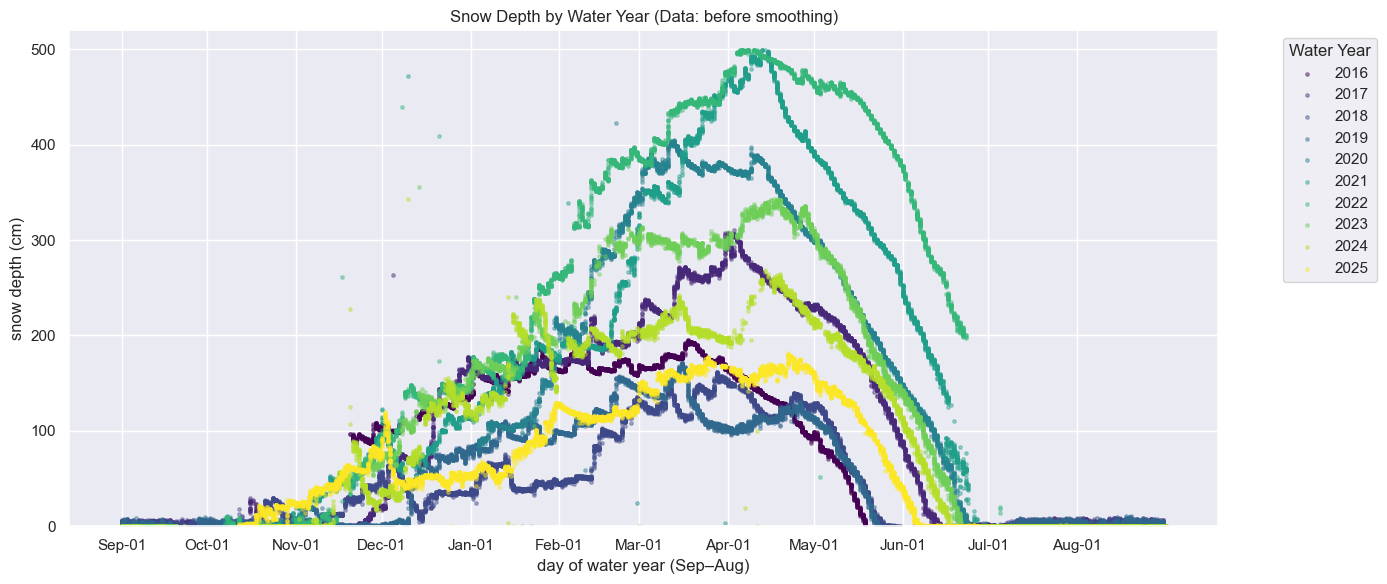

In [27]:
depth_col = 'hs_clean' 

# Drop NaNs
df_plot = df[[depth_col, 'snow_year_day', 'water_year']].dropna()

# Unique water years and color mapping
water_years = sorted(df_plot['water_year'].unique())
norm = mcolors.Normalize(vmin=min(water_years), vmax=max(water_years))
cmap = matplotlib.colormaps.get_cmap('viridis')  # ✅ Only 1 argument now

# Plot
plt.figure(figsize=(14, 6))

for year in water_years:
    year_data = df_plot[df_plot['water_year'] == year]
    color = cmap(norm(year))
    plt.scatter(
        year_data['snow_year_day'],
        year_data[depth_col],
        label=str(year),
        color=color,
        alpha=0.4,
        s=6
    )

# X-axis ticks
tick_locs = []
tick_labels = []
for month in range(9, 13):  # Sep–Dec
    tick_locs.append((pd.Timestamp(f'2020-{month:02d}-01') - pd.Timestamp('2020-09-01')).days)
    tick_labels.append(pd.Timestamp(f'2020-{month:02d}-01').strftime('%b-%d'))
for month in range(1, 9):   # Jan–Aug
    tick_locs.append((pd.Timestamp(f'2021-{month:02d}-01') - pd.Timestamp('2020-09-01')).days)
    tick_labels.append(pd.Timestamp(f'2021-{month:02d}-01').strftime('%b-%d'))

plt.xticks(tick_locs, tick_labels)

plt.xlabel('day of water year (Sep–Aug)')
plt.ylabel('snow depth (cm)')
# plt.title(f'{depth_col} Snow Depth by Water Year')
plt.title('Snow Depth by Water Year (Data: before smoothing)')
plt.grid(True)

# Legend
plt.legend(title='Water Year', bbox_to_anchor=(1.05, 1), loc='upper left')

#set the y-axis limits
plt.ylim(0, 520)

plt.tight_layout()
plt.show()

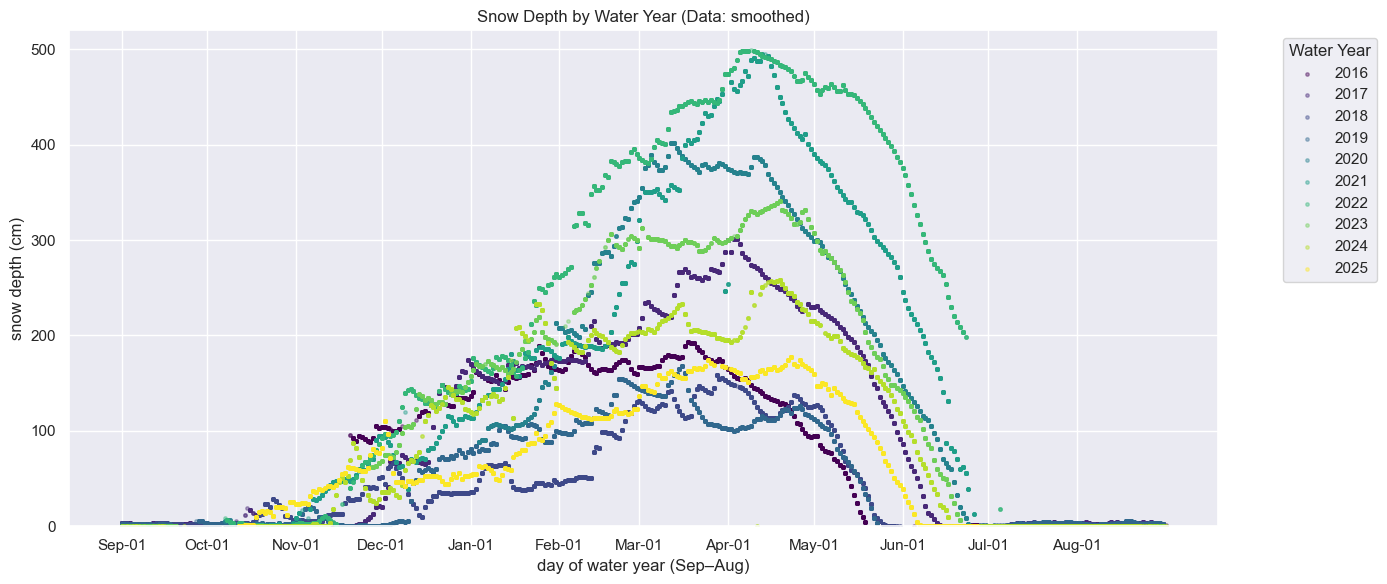

In [28]:
# depth_col = 'hs_smooth' 
depth_col = 'hs_smooth_001'
# depth_col = 'hs_smooth_005'

# Drop NaNs
df_plot = df[[depth_col, 'snow_year_day', 'water_year']].dropna()

# Unique water years and color mapping
water_years = sorted(df_plot['water_year'].unique())
norm = mcolors.Normalize(vmin=min(water_years), vmax=max(water_years))
cmap = matplotlib.colormaps.get_cmap('viridis')  # ✅ Only 1 argument now

# Plot
plt.figure(figsize=(14, 6))

for year in water_years:
    year_data = df_plot[df_plot['water_year'] == year]
    color = cmap(norm(year))
    plt.scatter(
        year_data['snow_year_day'],
        year_data[depth_col],
        label=str(year),
        color=color,
        alpha=0.4,
        s=6
    )

# X-axis ticks
tick_locs = []
tick_labels = []
for month in range(9, 13):  # Sep–Dec
    tick_locs.append((pd.Timestamp(f'2020-{month:02d}-01') - pd.Timestamp('2020-09-01')).days)
    tick_labels.append(pd.Timestamp(f'2020-{month:02d}-01').strftime('%b-%d'))
for month in range(1, 9):   # Jan–Aug
    tick_locs.append((pd.Timestamp(f'2021-{month:02d}-01') - pd.Timestamp('2020-09-01')).days)
    tick_labels.append(pd.Timestamp(f'2021-{month:02d}-01').strftime('%b-%d'))

plt.xticks(tick_locs, tick_labels)

plt.xlabel('day of water year (Sep–Aug)')
plt.ylabel('snow depth (cm)')
# plt.title(f'{depth_col} Snow Depth by Water Year')
plt.title('Snow Depth by Water Year (Data: smoothed)')
plt.grid(True)

# Legend
# increase the size of the colorbar showing in the legend
plt.legend(title='Water Year', bbox_to_anchor=(1.05, 1), loc='upper left')

#set the y-axis limits
plt.ylim(0, 520)

plt.tight_layout()
plt.show()

add a black trend line... 

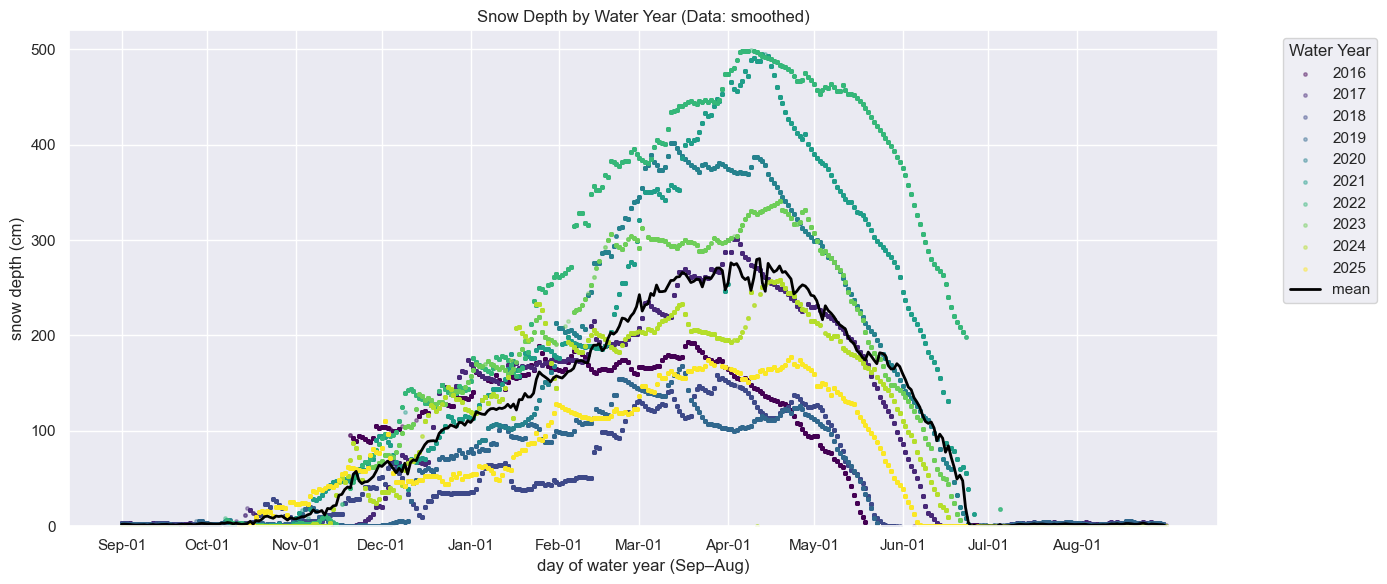

In [29]:
# depth_col = 'hs_smooth' 
depth_col = 'hs_smooth_001'
# depth_col = 'hs_smooth_005'

# Drop NaNs
df_plot = df[[depth_col, 'snow_year_day', 'water_year']].dropna()

# Unique water years and color mapping
water_years = sorted(df_plot['water_year'].unique())
norm = mcolors.Normalize(vmin=min(water_years), vmax=max(water_years))
cmap = matplotlib.colormaps.get_cmap('viridis')  # ✅ Only 1 argument now

# Plot
plt.figure(figsize=(14, 6))

for year in water_years:
    year_data = df_plot[df_plot['water_year'] == year]
    color = cmap(norm(year))
    plt.scatter(
        year_data['snow_year_day'],
        year_data[depth_col],
        label=str(year),
        color=color,
        alpha=0.4,
        s=6
    )

# X-axis ticks
tick_locs = []
tick_labels = []
for month in range(9, 13):  # Sep–Dec
    tick_locs.append((pd.Timestamp(f'2020-{month:02d}-01') - pd.Timestamp('2020-09-01')).days)
    tick_labels.append(pd.Timestamp(f'2020-{month:02d}-01').strftime('%b-%d'))
for month in range(1, 9):   # Jan–Aug
    tick_locs.append((pd.Timestamp(f'2021-{month:02d}-01') - pd.Timestamp('2020-09-01')).days)
    tick_labels.append(pd.Timestamp(f'2021-{month:02d}-01').strftime('%b-%d'))

plt.xticks(tick_locs, tick_labels)

plt.xlabel('day of water year (Sep–Aug)')
plt.ylabel('snow depth (cm)')
# plt.title(f'{depth_col} Snow Depth by Water Year')
plt.title('Snow Depth by Water Year (Data: smoothed)')
plt.grid(True)

# --- Calculate average snow depth by snow_year_day ---
mean_by_day = (
    df_plot
    .groupby('snow_year_day')[depth_col]
    .mean()
    .sort_index()
)

# Plot average trend line in black
plt.plot(
    mean_by_day.index,
    mean_by_day.values,
    color='black',
    linewidth=2,
    label='mean'
)

# Legend
# increase the size of the colorbar showing in the legend
plt.legend(title='Water Year', bbox_to_anchor=(1.05, 1), loc='upper left')

#set the y-axis limits
plt.ylim(0, 520)

plt.tight_layout()
plt.show()

Adjust alpha, make the lines gray?

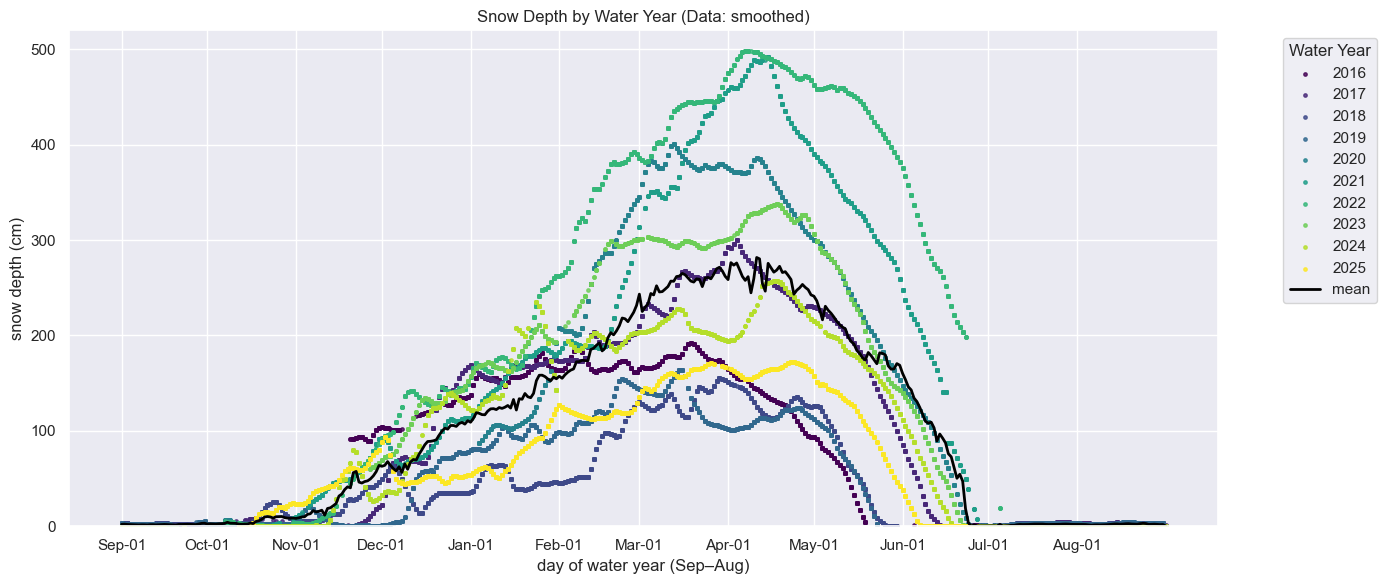

In [30]:
# depth_col = 'hs_smooth' 
# depth_col = 'hs_smooth_001'
depth_col = 'hs_smooth_002'
# depth_col = 'hs_smooth_005'

# Drop NaNs
df_plot = df[[depth_col, 'snow_year_day', 'water_year']].dropna()

# Unique water years and color mapping
water_years = sorted(df_plot['water_year'].unique())
norm = mcolors.Normalize(vmin=min(water_years), vmax=max(water_years))
cmap = matplotlib.colormaps.get_cmap('viridis')  # ✅ Only 1 argument now

# Plot
plt.figure(figsize=(14, 6))

for year in water_years:
    year_data = df_plot[df_plot['water_year'] == year]
    color = cmap(norm(year))
    plt.scatter(
        year_data['snow_year_day'],
        year_data[depth_col],
        label=str(year),
        color=color,
        alpha=0.8,
        s=6
    )

# X-axis ticks
tick_locs = []
tick_labels = []
for month in range(9, 13):  # Sep–Dec
    tick_locs.append((pd.Timestamp(f'2020-{month:02d}-01') - pd.Timestamp('2020-09-01')).days)
    tick_labels.append(pd.Timestamp(f'2020-{month:02d}-01').strftime('%b-%d'))
for month in range(1, 9):   # Jan–Aug
    tick_locs.append((pd.Timestamp(f'2021-{month:02d}-01') - pd.Timestamp('2020-09-01')).days)
    tick_labels.append(pd.Timestamp(f'2021-{month:02d}-01').strftime('%b-%d'))

plt.xticks(tick_locs, tick_labels)

plt.xlabel('day of water year (Sep–Aug)')
plt.ylabel('snow depth (cm)')
# plt.title(f'{depth_col} Snow Depth by Water Year')
plt.title('Snow Depth by Water Year (Data: smoothed)')
plt.grid(True)

# --- Calculate average snow depth by snow_year_day ---
mean_by_day = (
    df_plot
    .groupby('snow_year_day')[depth_col]
    .mean()
    .sort_index()
)

# Plot average trend line in black
plt.plot(
    mean_by_day.index,
    mean_by_day.values,
    color='black',
    linewidth=2,
    label='mean'
)

# Legend
# increase the size of the colorbar showing in the legend
plt.legend(title='Water Year', bbox_to_anchor=(1.05, 1), loc='upper left')

#set the y-axis limits
plt.ylim(0, 520)

plt.tight_layout()
plt.show()

In [38]:
from matplotlib.lines import Line2D

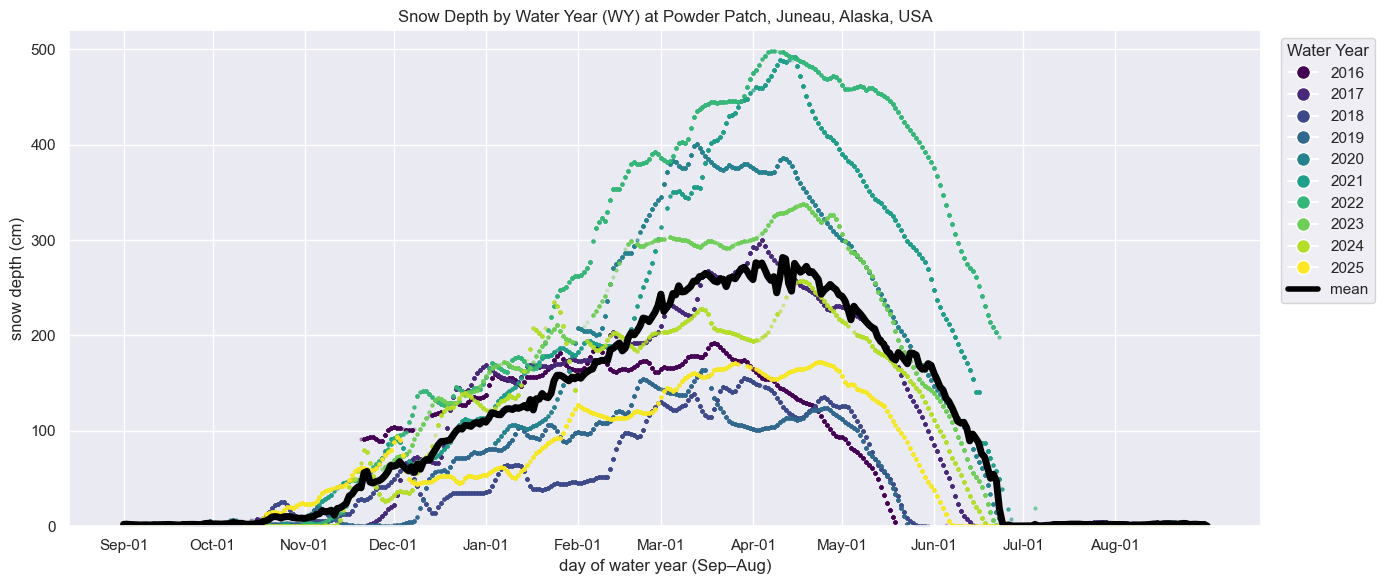

In [42]:
# depth_col = 'hs_smooth' 
# depth_col = 'hs_smooth_001'
depth_col = 'hs_smooth_002'
# depth_col = 'hs_smooth_005'

# Drop NaNs
df_plot = df[[depth_col, 'snow_year_day', 'water_year']].dropna()

# Unique water years and color mapping
water_years = sorted(df_plot['water_year'].unique())
norm = mcolors.Normalize(vmin=min(water_years), vmax=max(water_years))
cmap = matplotlib.colormaps.get_cmap('viridis')  # ✅ Only 1 argument now

# Plot
plt.figure(figsize=(14, 6))

for year in water_years:
    year_data = df_plot[df_plot['water_year'] == year]
    color = cmap(norm(year))
    plt.scatter(
        year_data['snow_year_day'],
        year_data[depth_col],
        label=str(year),
        color=color,
        alpha=0.2,
        s=4
    )

# X-axis ticks
tick_locs = []
tick_labels = []
for month in range(9, 13):  # Sep–Dec
    tick_locs.append((pd.Timestamp(f'2020-{month:02d}-01') - pd.Timestamp('2020-09-01')).days)
    tick_labels.append(pd.Timestamp(f'2020-{month:02d}-01').strftime('%b-%d'))
for month in range(1, 9):   # Jan–Aug
    tick_locs.append((pd.Timestamp(f'2021-{month:02d}-01') - pd.Timestamp('2020-09-01')).days)
    tick_labels.append(pd.Timestamp(f'2021-{month:02d}-01').strftime('%b-%d'))

plt.xticks(tick_locs, tick_labels)

plt.xlabel('day of water year (Sep–Aug)')
plt.ylabel('snow depth (cm)')
# plt.title(f'{depth_col} Snow Depth by Water Year')
plt.title('Snow Depth by Water Year (WY) at Powder Patch, Juneau, Alaska, USA')
plt.grid(True)

# --- Calculate average snow depth by snow_year_day ---
mean_by_day = (
    df_plot
    .groupby('snow_year_day')[depth_col]
    .mean()
    .sort_index()
)

# Plot average trend line in black
plt.plot(
    mean_by_day.index,
    mean_by_day.values,
    color='black',
    linewidth=5,
    label='mean'
)

# Legend
# increase the size of the colorbar showing in the legend
# plt.legend(title='Water Year', bbox_to_anchor=(1.05, 1), loc='upper left')

# Create custom legend handles
legend_elements = [
    Line2D(
        [0], [0], 
        marker='o', 
        color='w', 
        label=str(year), 
        markerfacecolor=cmap(norm(year)), 
        markersize=10  # 👈 Increase this value for larger dots
    )
    for year in water_years
]

# Add 'mean' line to the legend
legend_elements.append(
    Line2D(
        [0], [0], 
        color='black', 
        lw=4, 
        label='mean'
    )
)

# Show legend with custom handles
plt.legend(
    handles=legend_elements, 
    title='Water Year',
    bbox_to_anchor=(1.01, 1), 
    loc='upper left'
)

#set the y-axis limits
plt.ylim(0, 520)

plt.tight_layout()
plt.show()

In [32]:
df

,hs,datetime,water_year,hs_clean,doy,water_doy,water_year_start,day_since_first_wy,hs_smooth,hs_smooth_001,hs_smooth_002,hs_smooth_005,snow_year_day
datetime,,,,,,,,,,,,,
2015-11-20 22:00:00,96.2914,2015-11-20 22:00:00,2016,96.2914,324,51,2015-10-01,780,88.322523,95.836258,91.615085,91.548294,80
2015-11-20 23:00:00,96.2914,2015-11-20 23:00:00,2016,96.2914,324,51,2015-10-01,780,88.322523,95.836258,91.615085,91.548294,80
2015-11-21 00:00:00,95.1992,2015-11-21 00:00:00,2016,95.1992,325,52,2015-10-01,781,89.381671,92.736468,91.936690,91.640169,81
2015-11-21 01:00:00,94.5896,2015-11-21 01:00:00,2016,94.5896,325,52,2015-10-01,781,89.381671,92.736468,91.936690,91.640169,81
2015-11-21 02:00:00,94.5896,2015-11-21 02:00:00,2016,94.5896,325,52,2015-10-01,781,89.381671,92.736468,91.936690,91.640169,81
...,...,...,...,...,...,...,...,...,...,...,...,...,...
2025-06-27 08:00:00,0.3810,2025-06-27 08:00:00,2025,0.3810,178,270,2024-10-01,4287,NaN,0.070126,0.188236,0.139855,299
2025-06-27 09:00:00,0.0000,2025-06-27 09:00:00,2025,0.0000,178,270,2024-10-01,4287,NaN,0.070126,0.188236,0.139855,299
2025-06-27 10:00:00,0.0000,2025-06-27 10:00:00,2025,0.0000,178,270,2024-10-01,4287,NaN,0.070126,0.188236,0.139855,299


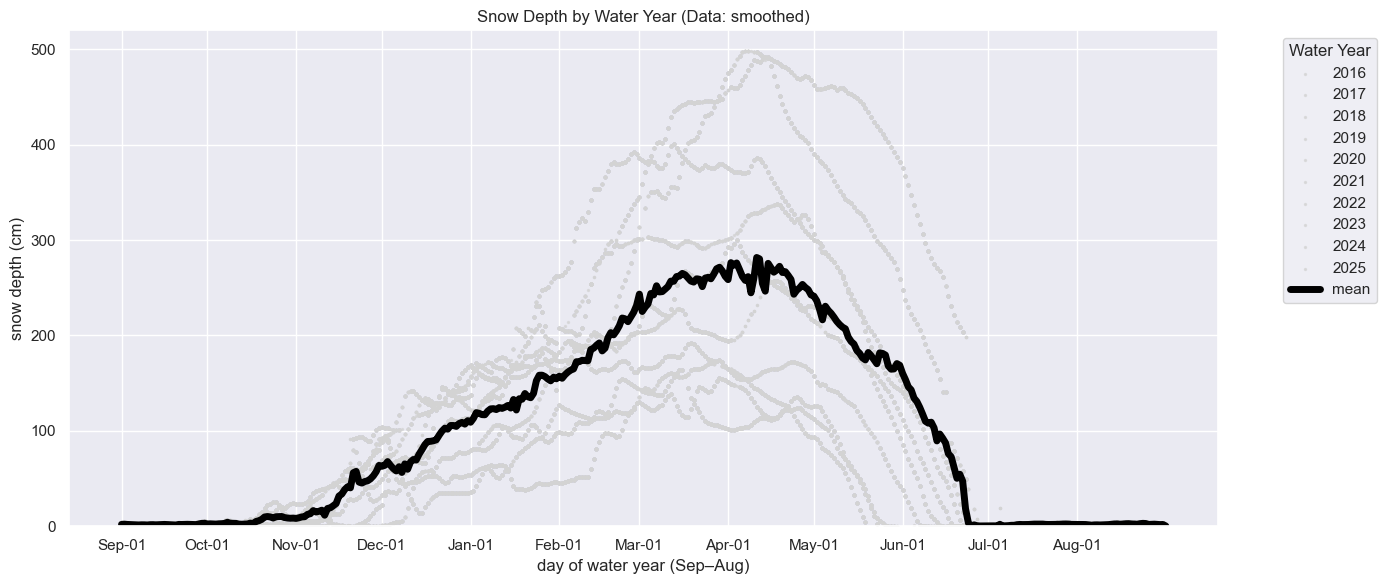

In [33]:
# depth_col = 'hs_smooth' 
# depth_col = 'hs_smooth_001'
depth_col = 'hs_smooth_002'
# depth_col = 'hs_smooth_005'

# Drop NaNs
df_plot = df[[depth_col, 'snow_year_day', 'water_year']].dropna()

# Plot
plt.figure(figsize=(14, 6))

for year in water_years:
    year_data = df_plot[df_plot['water_year'] == year]
    plt.scatter(
        year_data['snow_year_day'],
        year_data[depth_col],
        label=str(year),
        color='lightgrey',
        alpha=0.7,
        s=2
    )

# X-axis ticks
tick_locs = []
tick_labels = []
for month in range(9, 13):  # Sep–Dec
    tick_locs.append((pd.Timestamp(f'2020-{month:02d}-01') - pd.Timestamp('2020-09-01')).days)
    tick_labels.append(pd.Timestamp(f'2020-{month:02d}-01').strftime('%b-%d'))
for month in range(1, 9):   # Jan–Aug
    tick_locs.append((pd.Timestamp(f'2021-{month:02d}-01') - pd.Timestamp('2020-09-01')).days)
    tick_labels.append(pd.Timestamp(f'2021-{month:02d}-01').strftime('%b-%d'))

plt.xticks(tick_locs, tick_labels)

plt.xlabel('day of water year (Sep–Aug)')
plt.ylabel('snow depth (cm)')
# plt.title(f'{depth_col} Snow Depth by Water Year')
plt.title('Snow Depth by Water Year (Data: smoothed)')
plt.grid(True)

# --- Calculate average snow depth by snow_year_day ---
mean_by_day = (
    df_plot
    .groupby('snow_year_day')[depth_col]
    .mean()
    .sort_index()
)

# Plot average trend line in black
plt.plot(
    mean_by_day.index,
    mean_by_day.values,
    color='black',
    linewidth=5,
    label='mean'
)

# Legend
# increase the size of the colorbar showing in the legend
plt.legend(title='Water Year', bbox_to_anchor=(1.05, 1), loc='upper left')

#set the y-axis limits
plt.ylim(0, 520)

plt.tight_layout()
plt.show()

Messing with plotting, 

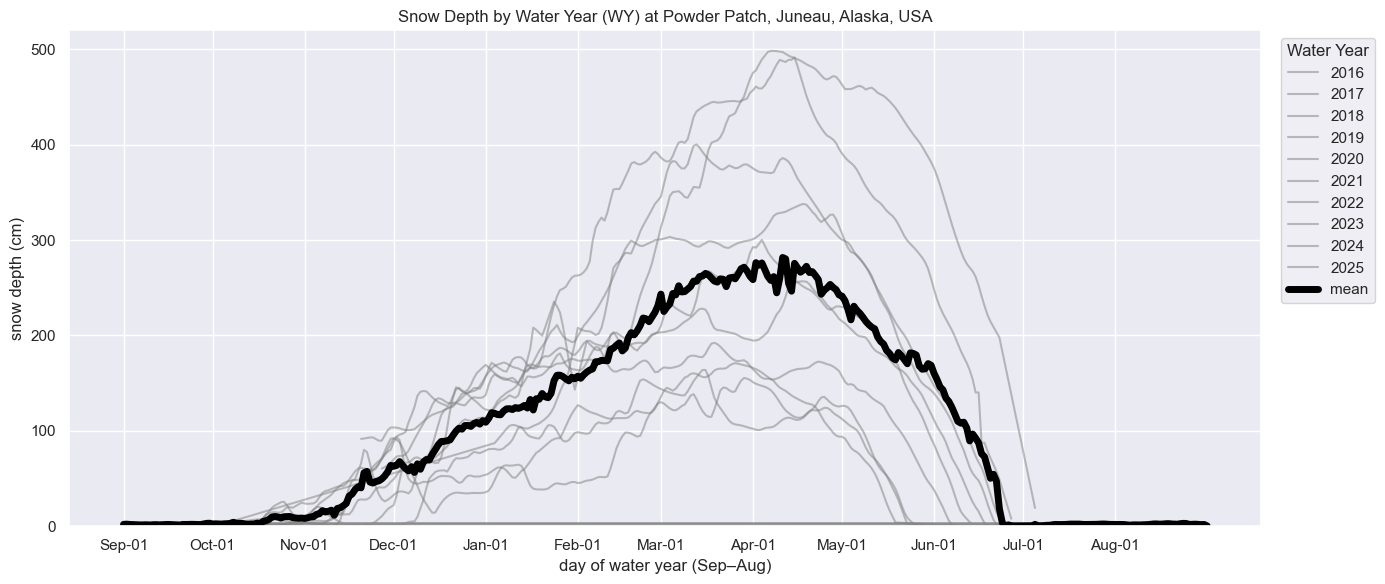

In [44]:
# depth_col = 'hs_smooth' 
# depth_col = 'hs_smooth_001'
depth_col = 'hs_smooth_002'
# depth_col = 'hs_smooth_005'

# Drop NaNs
df_plot = df[[depth_col, 'snow_year_day', 'water_year']].dropna()

# Plot
plt.figure(figsize=(14, 6))

for year in water_years:
    year_data = df_plot[df_plot['water_year'] == year]
    plt.plot(
        year_data['snow_year_day'],
        year_data[depth_col],
        label=str(year),
        color='grey',
        alpha=0.5,
        # s=6
    )

# X-axis ticks
tick_locs = []
tick_labels = []
for month in range(9, 13):  # Sep–Dec
    tick_locs.append((pd.Timestamp(f'2020-{month:02d}-01') - pd.Timestamp('2020-09-01')).days)
    tick_labels.append(pd.Timestamp(f'2020-{month:02d}-01').strftime('%b-%d'))
for month in range(1, 9):   # Jan–Aug
    tick_locs.append((pd.Timestamp(f'2021-{month:02d}-01') - pd.Timestamp('2020-09-01')).days)
    tick_labels.append(pd.Timestamp(f'2021-{month:02d}-01').strftime('%b-%d'))

plt.xticks(tick_locs, tick_labels)

plt.xlabel('day of water year (Sep–Aug)')
plt.ylabel('snow depth (cm)')
# plt.title(f'{depth_col} Snow Depth by Water Year')
# plt.title('Snow Depth by Water Year (Data: smoothed)')
plt.title('Snow Depth by Water Year (WY) at Powder Patch, Juneau, Alaska, USA')
plt.grid(True)

# --- Calculate average snow depth by snow_year_day ---
mean_by_day = (
    df_plot
    .groupby('snow_year_day')[depth_col]
    .mean()
    .sort_index()
)

# Plot average trend line in black
plt.plot(
    mean_by_day.index,
    mean_by_day.values,
    color='black',
    linewidth=5,
    label='mean'
)

# Legend
# increase the size of the colorbar showing in the legend
plt.legend(title='Water Year', bbox_to_anchor=(1.01, 1), loc='upper left')

#set the y-axis limits
plt.ylim(0, 520)

plt.tight_layout()
plt.show()

Text(0.5, 0, '')

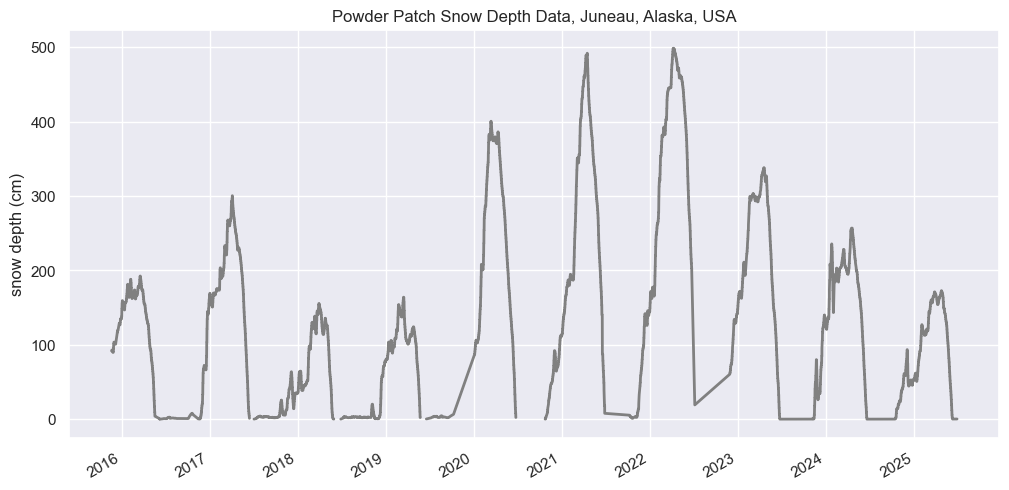

In [47]:
plt.figure(figsize=(12, 6))
plt.title('Powder Patch Snow Depth Data, Juneau, Alaska, USA')
plt.ylabel('snow depth (cm)')
df['hs_smooth_002'].plot(label='smoothed', color='grey', linewidth=2)

# plt.legend(loc='upper left')
plt.xlabel('')

Text(0.5, 0, 'datetime')

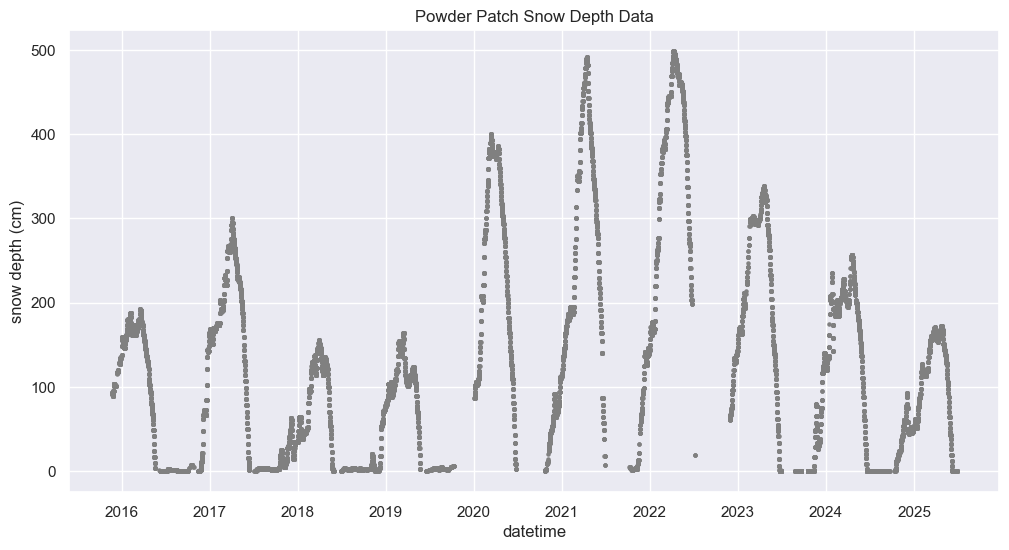

In [45]:
plt.figure(figsize=(12, 6))
plt.title('Powder Patch Snow Depth Data')
plt.ylabel('snow depth (cm)')
plt.scatter(
    df['datetime'],
    df['hs_smooth_002'],
    label='smooth snow depth',
    color='grey',
    s=5
)
# df['hs_smooth_002'].scatter(label='smoothed', color='black', s=2)

# plt.legend(loc='upper left')
plt.xlabel('datetime')

Get back the connected lines...

/tmp/ipykernel_902535/2997043846.py:12: MatplotlibDeprecationWarning: The get_cmap function was deprecated in Matplotlib 3.7 and will be removed in 3.11. Use ``matplotlib.colormaps[name]`` or ``matplotlib.colormaps.get_cmap()`` or ``pyplot.get_cmap()`` instead.
  cmap = cm.get_cmap('viridis', len(water_years))


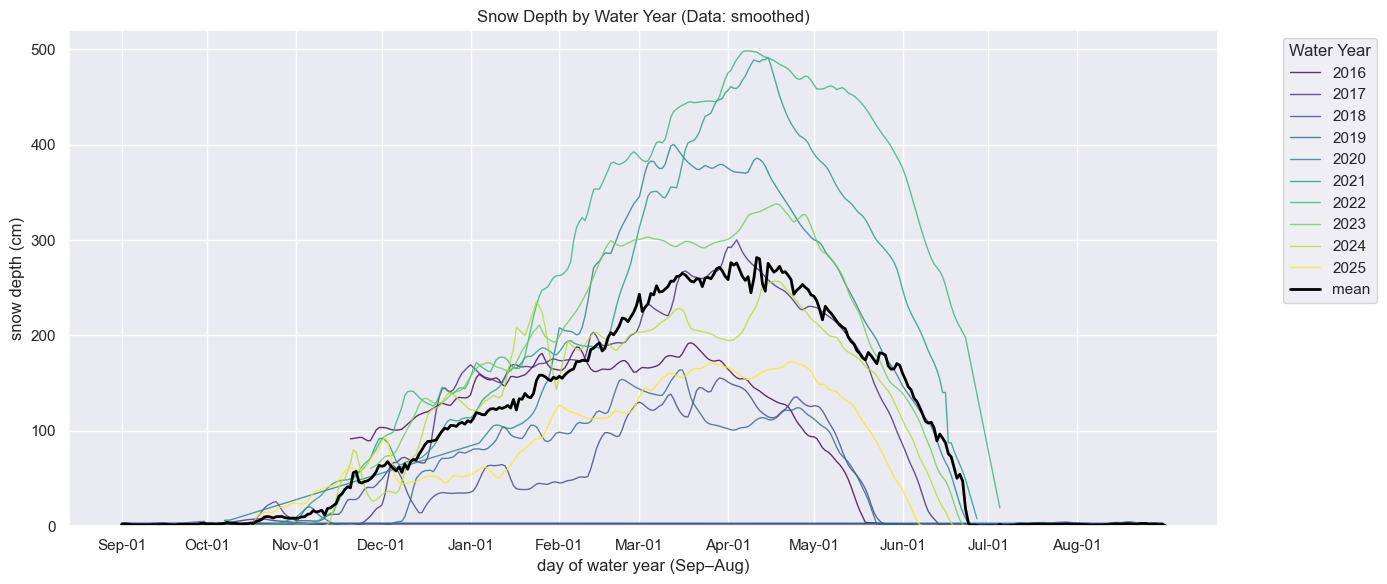

In [37]:
# Choose snow depth column to plot
# depth_col = 'hs_smooth_001'
depth_col = 'hs_smooth_002'
# depth_col = 'hs_smooth_005'

# Drop NaN values for that column
df_plot = df[[depth_col, 'snow_year_day', 'water_year']].dropna()

# Set up unique years and colors
water_years = sorted(df_plot['water_year'].unique())
norm = mcolors.Normalize(vmin=min(water_years), vmax=max(water_years))
cmap = cm.get_cmap('viridis', len(water_years))
sm = cm.ScalarMappable(norm=norm, cmap=cmap)  # for legend

# Create plot
plt.figure(figsize=(14, 6))

for i, year in enumerate(water_years):
    year_data = df_plot[df_plot['water_year'] == year]
    color = cmap(norm(year))
    plt.plot(
        year_data['snow_year_day'],
        year_data[depth_col],
        label=str(year),
        color=color,
        alpha=0.8,
        linewidth=1
    )

# Customize x-axis ticks (same as before)
tick_locs = []
tick_labels = []
for month in range(9, 13):  # Sep–Dec
    tick_locs.append((pd.Timestamp(f'2020-{month:02d}-01') - pd.Timestamp('2020-09-01')).days)
    tick_labels.append(pd.Timestamp(f'2020-{month:02d}-01').strftime('%b-%d'))
for month in range(1, 9):   # Jan–Aug
    tick_locs.append((pd.Timestamp(f'2021-{month:02d}-01') - pd.Timestamp('2020-09-01')).days)
    tick_labels.append(pd.Timestamp(f'2021-{month:02d}-01').strftime('%b-%d'))


plt.xticks(tick_locs, tick_labels)

plt.xlabel('day of water year (Sep–Aug)')
plt.ylabel('snow depth (cm)')
# plt.title(f'{depth_col} Snow Depth by Water Year')
plt.title('Snow Depth by Water Year (Data: smoothed)')
plt.grid(True)

# --- Calculate average snow depth by snow_year_day ---
mean_by_day = (
    df_plot
    .groupby('snow_year_day')[depth_col]
    .mean()
    .sort_index()
)

# Plot average trend line in black
plt.plot(
    mean_by_day.index,
    mean_by_day.values,
    color='black',
    linewidth=2,
    label='mean'
)

# Legend
# increase the size of the colorbar showing in the legend
plt.legend(title='Water Year', bbox_to_anchor=(1.05, 1), loc='upper left')

#set the y-axis limits
plt.ylim(0, 520)

plt.tight_layout()
plt.show()